In [1]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50, ConvNeXtLarge
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, GlobalMaxPooling2D, GlobalAveragePooling2D
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
data_dir = "ePillID_data/classification_data/segmented_nih_pills_224"

In [ ]:
# load the models
resnet_50 = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3)) # just classic at this point
convnet_large = ConvNeXtLarge(weights='imagenet', include_top=False, input_shape=(224,224,3)) # seemed like it had great accuracy and decent size for computation so I opted for it

In [3]:
# preping the last layer
# if we want to check any other network, can just replace the names from here
last_conv_layer_output = convnet_large.output # last layer of the network
firtst_layer_inputs = convnet_large.input # input of the network
# three different approaches
flatten_model = Model(inputs=firtst_layer_inputs, outputs=Flatten()(last_conv_layer_output)) # flatten
gmp_model = Model(inputs=firtst_layer_inputs, outputs=GlobalMaxPooling2D()(last_conv_layer_output)) # maxpool
gap_model = Model(inputs=firtst_layer_inputs, outputs=GlobalAveragePooling2D()(last_conv_layer_output)) #avgpool

In [6]:
# all the images inside the segmented_nih_pills_224
all_img_paths = [os.path.join(data_dir, f) for f in os.listdir(data_dir)]
all_img_paths = all_img_paths[:500] # amount of images to be processed 

In [7]:
# load the image, process it then extract the features
def load_and_preprocess(img_path):
    img = image.load_img(img_path, target_size=(224,224)) # just making sure the images are all the same size even tho seems like all of them are preprocessed
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) # need to add a batch dimension for the models
    x = preprocess_input(x)
    return x
def extract_features(model):
    features = []
    for path in tqdm(all_img_paths, desc="Extracting features"):
        img = load_and_preprocess(path)
        feat = model.predict(img, verbose=0)
        features.append(feat.flatten())
    return np.array(features)
# extract the features for all three different approaches
features_flatten = extract_features(flatten_model)
features_gmp = extract_features(gmp_model)
features_gap = extract_features(gap_model)

Extracting features: 100%|██████████| 500/500 [03:12<00:00,  2.60it/s]


In [8]:
# similarity computation with cosine_similarity
def find_similar_images(query_idx, features, top_n=10):
    sims = cosine_similarity([features[query_idx]], features)[0]
    sorted_idx = np.argsort(-sims)  # descending
    top_indices = sorted_idx[1:top_n+1]  # skip itself
    return top_indices, sims[top_indices]

In [9]:
def show_similar_images(query_idx, features_dict, all_img_paths, query_title="Query Image"):
    n_methods = len(features_dict)
    n_similar = 10  # show top-10 similar images per method

    plt.figure(figsize=(15, 5 * n_methods))
    query_img = image.load_img(all_img_paths[query_idx]) # image to compare with
    
    for row_idx, (method_name, features) in enumerate(features_dict.items()):
        top_indices, sims = find_similar_images(query_idx, features, top_n=n_similar) # compute similarities

        # can be uncommented to not show the query image in every row but this way it looks better
        # if row_idx == 0: 
        plt.subplot(n_methods, n_similar + 1, row_idx * (n_similar + 1) + 1)
        plt.imshow(query_img)
        plt.title(query_title)
        plt.axis('off')

        for i, idx in enumerate(top_indices): # top n_similar images for each single method
            plt.subplot(n_methods, n_similar + 1, row_idx * (n_similar + 1) + i + 2)
            plt.imshow(image.load_img(all_img_paths[idx]))
            plt.title(f"{method_name}\n{(sims[i]):.2f}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

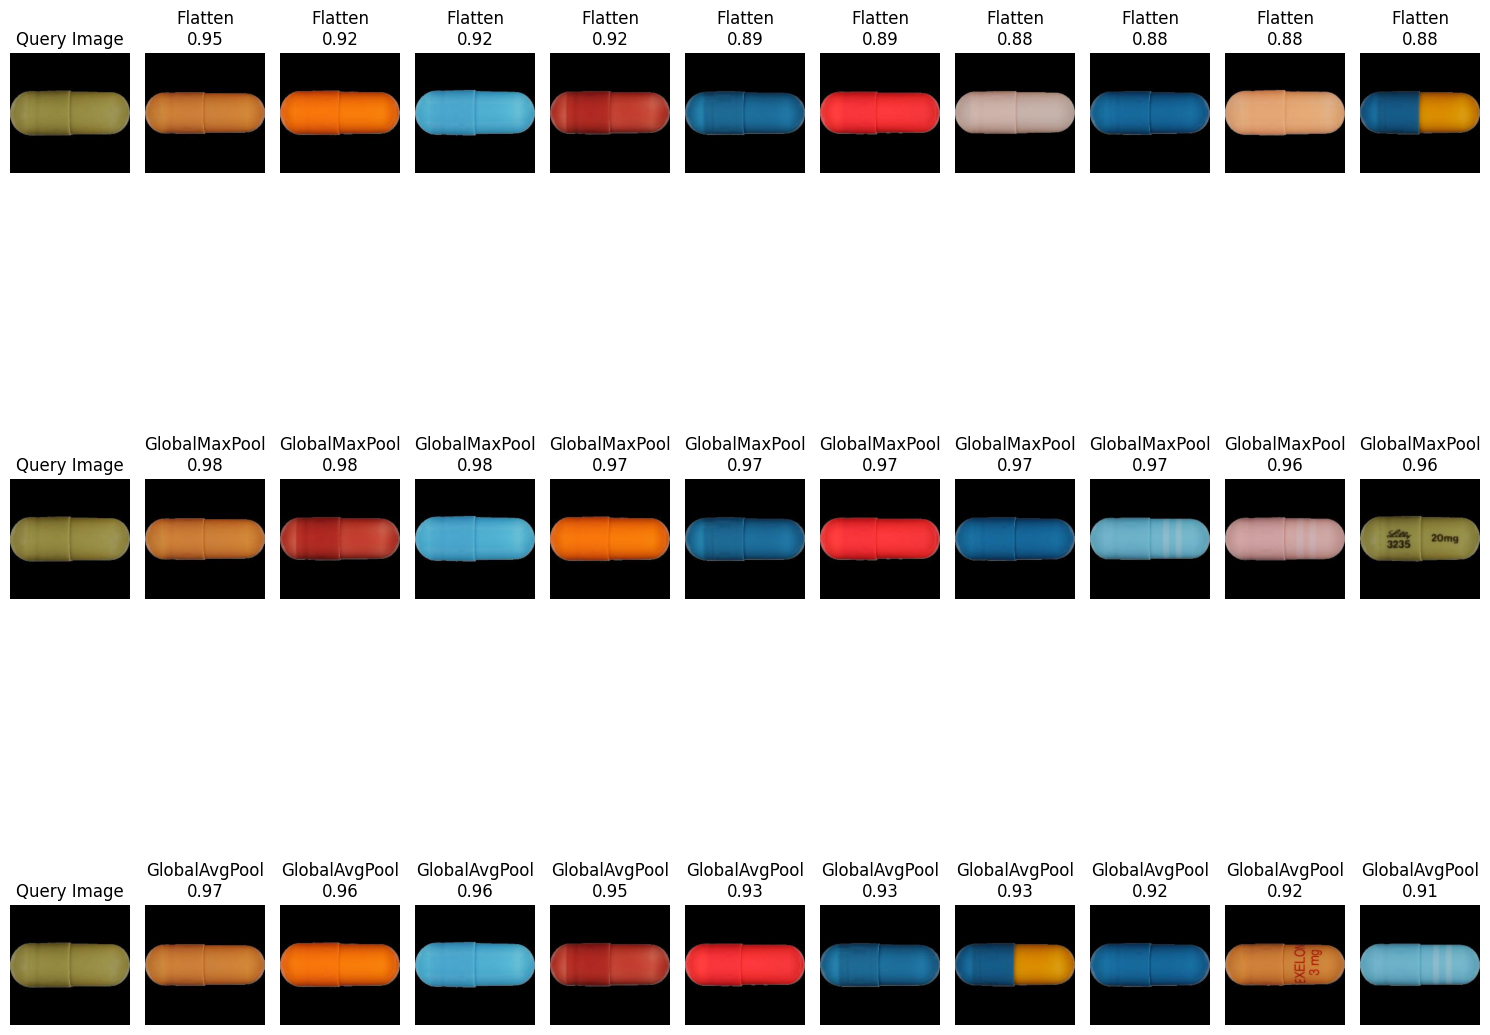

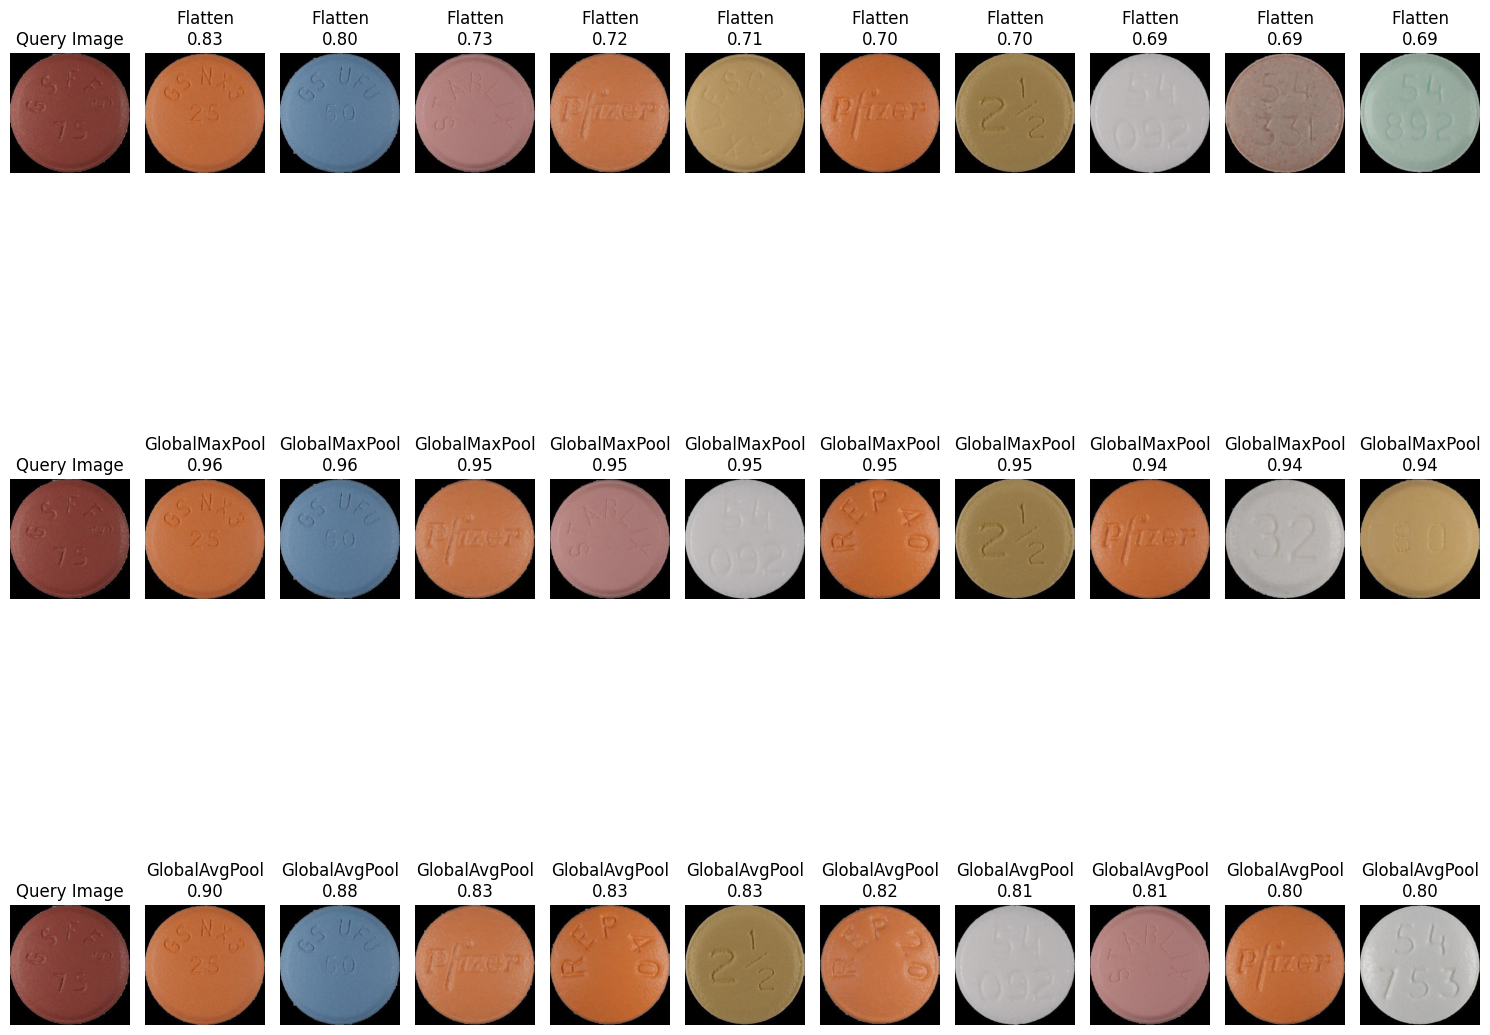

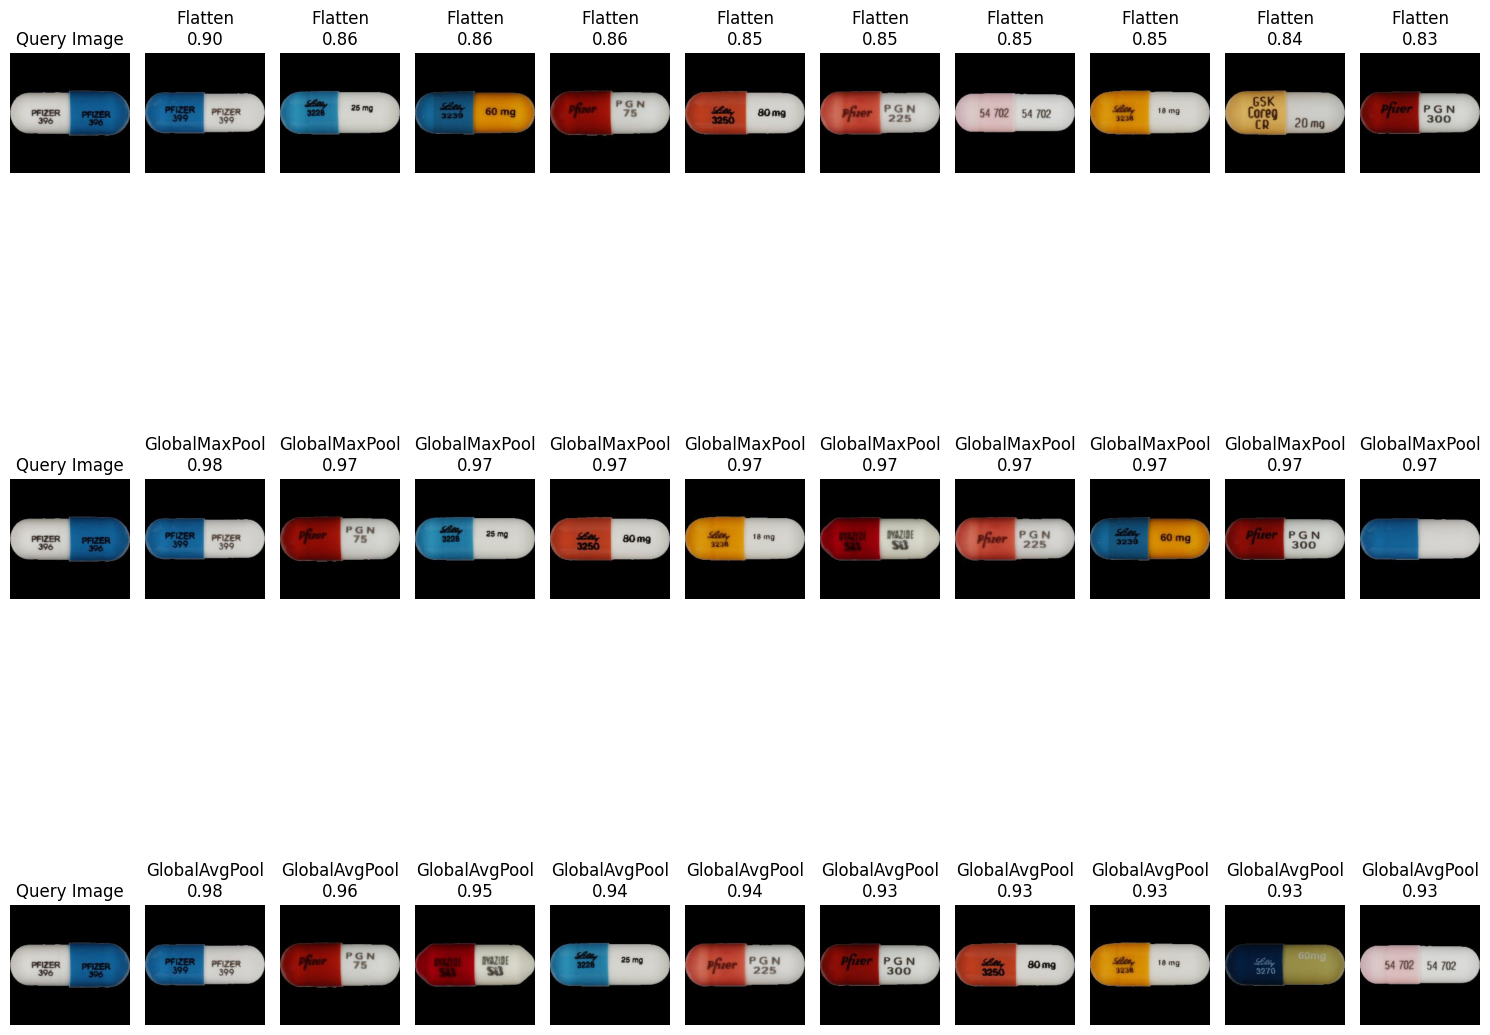

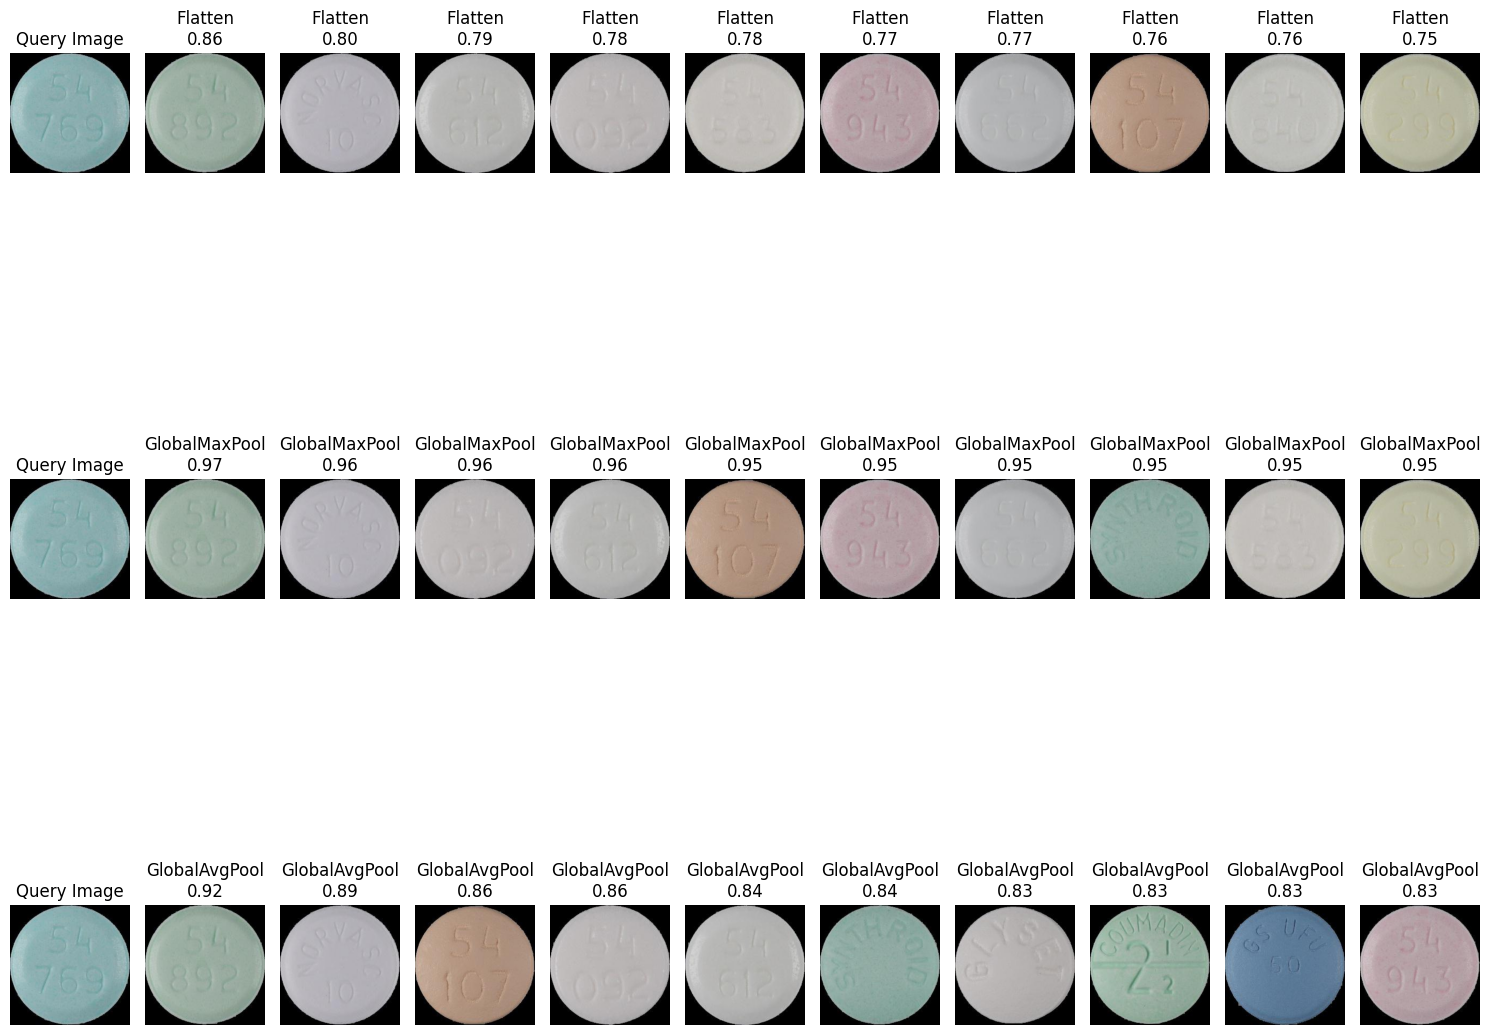

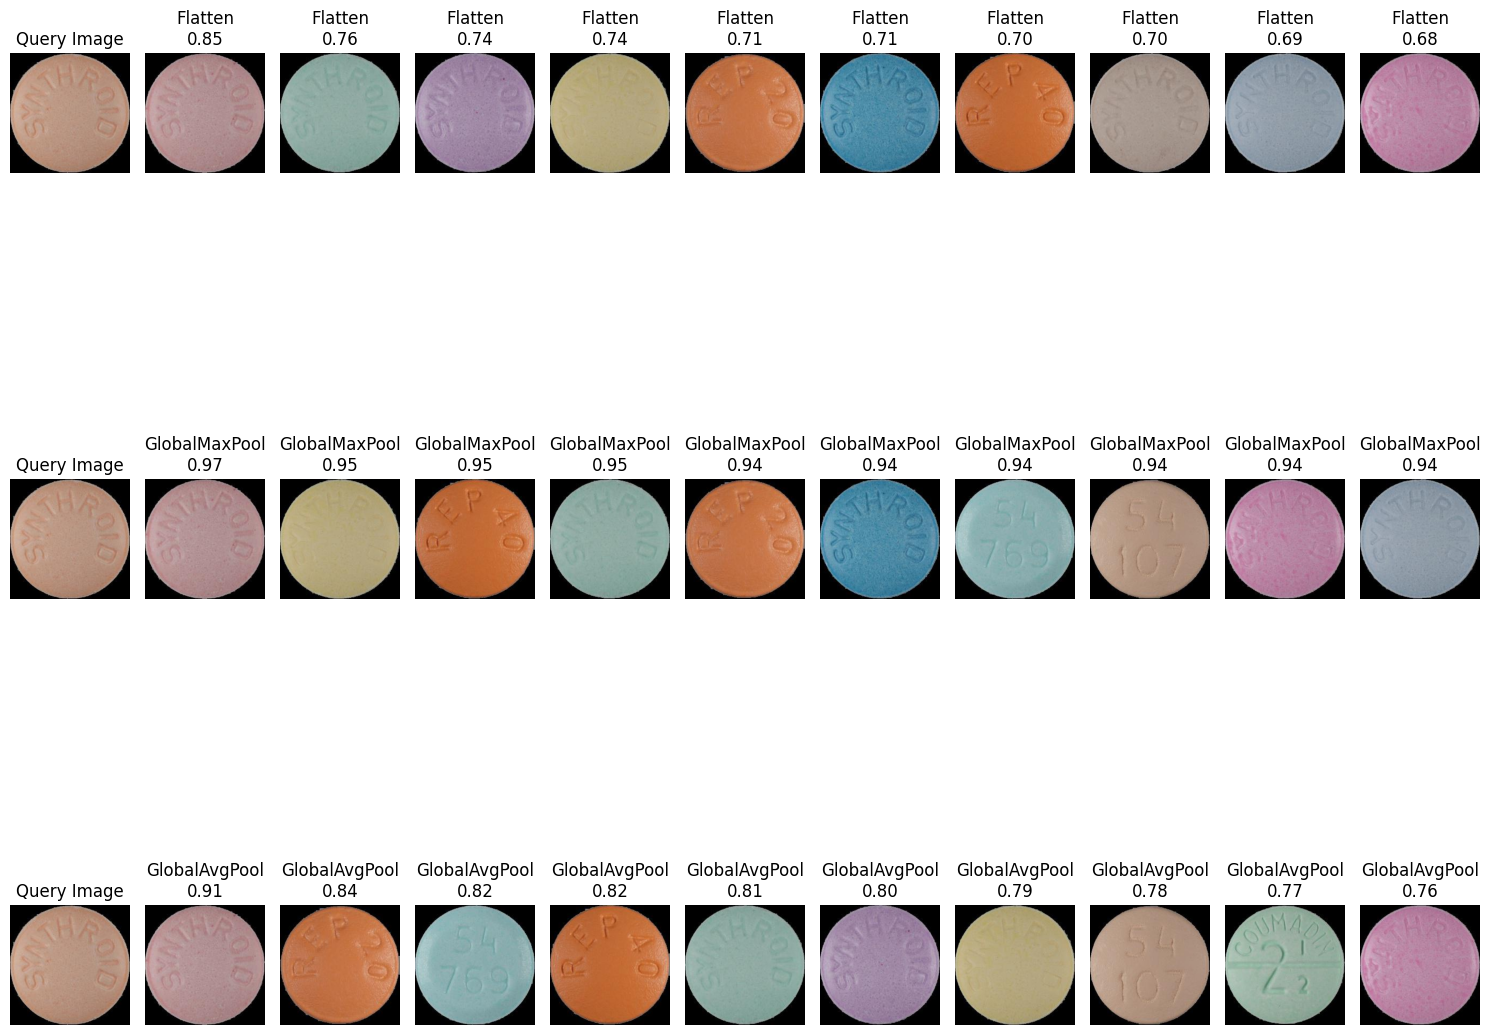

In [10]:
features_dict = {
    "Flatten": features_flatten,
    "GlobalMaxPool": features_gmp,
    "GlobalAvgPool": features_gap
}

for query_idx in [5, 100, 200, 300, 400]:
    show_similar_images(query_idx, features_dict, all_img_paths)